# 🎮 Hutch Games Analytics Project
## Notebook 05 — Monetization & LTV Analysis

**Analyst:** Ebi Mologe  
**Dataset:** `players.csv` + `loot_events.csv` + `segments_truth.csv` + `daily_activity.csv`  

**Objective:** Analyse monetization and LTV-style metrics across:
- Player segments (Casual, Grinder-F2W, Spender, Whale, Churned-early).
- Acquisition channels (Organic, Meta Ads, Google UAC, TikTok Ads, etc.).
- AB groups (control vs variant legendary chest).

This notebook connects retention and funnel results to actual value per player
(payer conversion, ARPU, LTV proxy) to support UA and design decisions.

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path('/Users/ebimol/GamesAnalyticsProject')
OUT_DIR  = DATA_DIR / 'outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.dpi']     = 150
plt.rcParams['figure.figsize'] = (12, 5)
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860', '#DA8BC3']
sns.set_theme(style='whitegrid', palette=PALETTE)

print('Libraries loaded ✓')
print('DATA_DIR:', DATA_DIR)
print('OUT_DIR :', OUT_DIR)

Libraries loaded ✓
DATA_DIR: /Users/ebimol/GamesAnalyticsProject
OUT_DIR : /Users/ebimol/GamesAnalyticsProject/outputs


## 2. Load Data

In [2]:
players        = pd.read_csv(DATA_DIR / 'players.csv',
                             parse_dates=['install_date','last_active_date'])
segments_truth = pd.read_csv(DATA_DIR / 'segments_truth.csv')
loot_events    = pd.read_csv(DATA_DIR / 'loot_events.csv',
                             parse_dates=['first_legendary_date'])
daily_activity = pd.read_csv(DATA_DIR / 'daily_activity.csv',
                             parse_dates=['date'])

print(f'players shape        : {players.shape}')
print(f'segments_truth shape: {segments_truth.shape}')
print(f'loot_events shape    : {loot_events.shape}')
print(f'daily_activity shape : {daily_activity.shape}')

print('\nSegment distribution (true_segment):')
print(segments_truth['true_segment'].value_counts())

print('\nAB groups (players):')
print(players['ab_group'].value_counts())

print('\nAcquisition channels:')
print(players['acquisition_channel'].value_counts())

players shape        : (30000, 22)
segments_truth shape: (30000, 2)
loot_events shape    : (30000, 10)
daily_activity shape : (208310, 12)

Segment distribution (true_segment):
true_segment
Casual           13528
Churned-early    10635
Grinder-F2W       4832
Spender            867
Whale              138
Name: count, dtype: int64

AB groups (players):
ab_group
variant    15013
control    14987
Name: count, dtype: int64

Acquisition channels:
acquisition_channel
Organic             9155
Meta Ads            6421
Google UAC          5885
TikTok Ads          3639
Apple Search Ads    2466
Cross-promo         1507
Influencer           927
Name: count, dtype: int64


In [3]:
# Merge players with ground-truth segments
df = players.merge(segments_truth, on='player_id', how='left')
assert df['true_segment'].notnull().all(), 'Missing true_segment labels after merge!'
print('All players have true_segment labels ✓')

# Segment-level monetization overview
seg_monet = df.groupby('true_segment').agg({
    'player_id'      : 'count',
    'is_payer'       : 'mean',
    'total_iap_usd'  : 'mean',
    'currency_spent_total': 'mean',
    'gems_spent_total'    : 'mean',
}).rename(columns={
    'player_id'     : 'N_players',
    'is_payer'      : 'payer_rate',
    'total_iap_usd' : 'avg_iap_usd',
})

print('\nMonetization by true_segment (raw):')
display(seg_monet)

seg_display = seg_monet.copy()
seg_display['payer_rate']   = seg_display['payer_rate'].map(lambda x: f'{x:.1%}')
seg_display['avg_iap_usd']  = seg_display['avg_iap_usd'].map(lambda x: f'{x:.2f}')
seg_display['currency_spent_total'] = seg_display['currency_spent_total'].map(lambda x: f'{x:.0f}')
seg_display['gems_spent_total']     = seg_display['gems_spent_total'].map(lambda x: f'{x:.0f}')

print('\nMonetization by true_segment (formatted):')
display(seg_display)

All players have true_segment labels ✓

Monetization by true_segment (raw):


,N_players,payer_rate,avg_iap_usd,currency_spent_total,gems_spent_total
true_segment,,,,,
Casual,13528,0.007688,0.068958,823.691233,164.113099
Churned-early,10635,0.000940,0.004816,125.586460,11.597743
Grinder-F2W,4832,0.041391,0.536612,5768.757243,1202.639901
Spender,867,0.776240,49.360138,12039.643599,7567.371396
Whale,138,0.913043,428.124565,47013.942029,44140.608696



Monetization by true_segment (formatted):


,N_players,payer_rate,avg_iap_usd,currency_spent_total,gems_spent_total
true_segment,,,,,
Casual,13528,0.8%,0.07,824,164
Churned-early,10635,0.1%,0.00,126,12
Grinder-F2W,4832,4.1%,0.54,5769,1203
Spender,867,77.6%,49.36,12040,7567
Whale,138,91.3%,428.12,47014,44141


## 3. Monetization by Acquisition Channel

We now look at payer rate and average IAP per player by acquisition_channel
(Organic, Meta Ads, Google UAC, TikTok Ads, etc.).

This approximates channel-level LTV and helps identify high-quality UA sources.

In [4]:
channel_monet = df.groupby('acquisition_channel').agg({
    'player_id'     : 'count',
    'is_payer'      : 'mean',
    'total_iap_usd' : 'mean',
}).rename(columns={
    'player_id'     : 'N_players',
    'is_payer'      : 'payer_rate',
    'total_iap_usd' : 'avg_iap_usd',
}).sort_values('avg_iap_usd', ascending=False)

print('Monetization by acquisition_channel (raw):')
display(channel_monet)

channel_display = channel_monet.copy()
channel_display['payer_rate']  = channel_display['payer_rate'].map(lambda x: f'{x:.1%}')
channel_display['avg_iap_usd'] = channel_display['avg_iap_usd'].map(lambda x: f'{x:.2f}')

print('\nMonetization by acquisition_channel (formatted):')
display(channel_display)

Monetization by acquisition_channel (raw):


,N_players,payer_rate,avg_iap_usd
acquisition_channel,,,
Apple Search Ads,2466,0.039335,6.202778
Meta Ads,6421,0.035820,3.577687
Organic,9155,0.038230,3.372036
Google UAC,5885,0.035514,3.195910
Cross-promo,1507,0.039814,3.000551
TikTok Ads,3639,0.038747,2.961173
Influencer,927,0.028047,2.382503



Monetization by acquisition_channel (formatted):


,N_players,payer_rate,avg_iap_usd
acquisition_channel,,,
Apple Search Ads,2466,3.9%,6.20
Meta Ads,6421,3.6%,3.58
Organic,9155,3.8%,3.37
Google UAC,5885,3.6%,3.20
Cross-promo,1507,4.0%,3.00
TikTok Ads,3639,3.9%,2.96
Influencer,927,2.8%,2.38


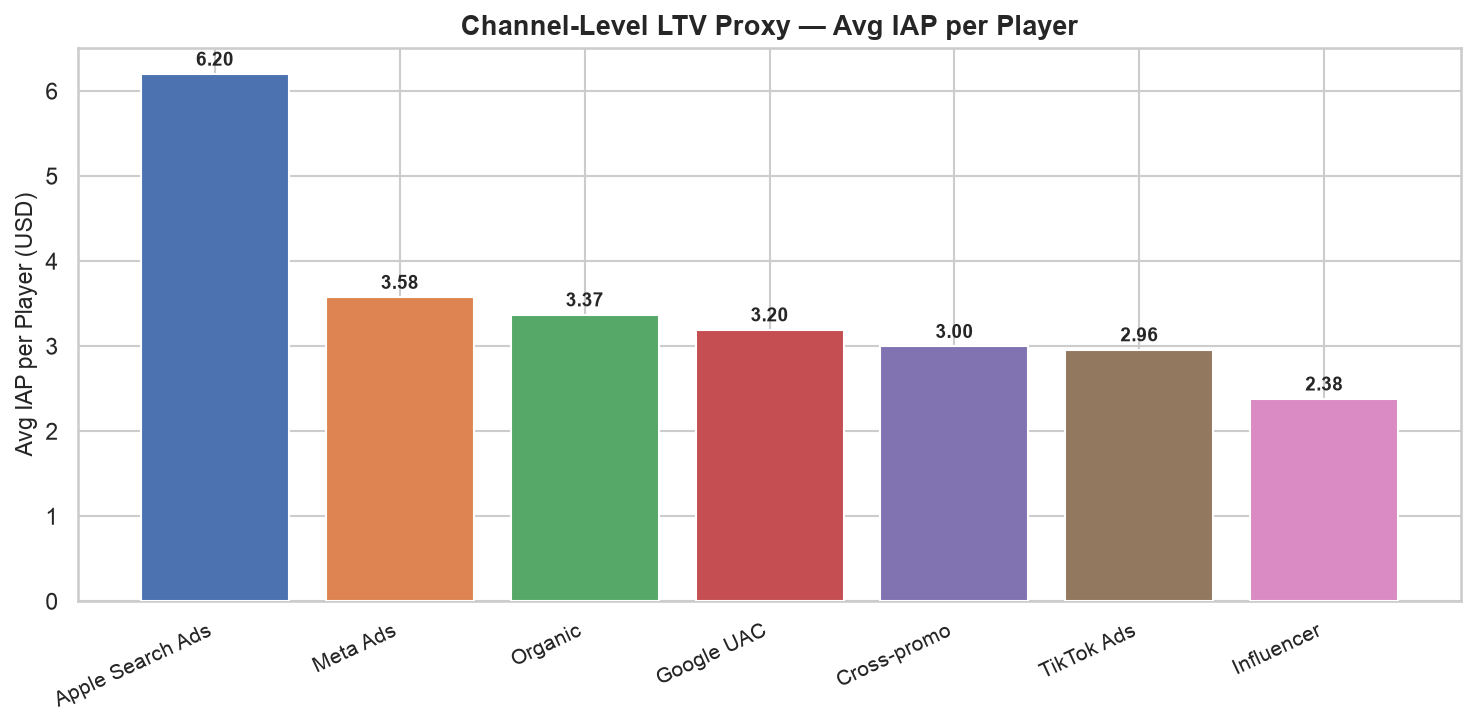

Chart saved ✓


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

channels = channel_monet.index.tolist()
vals = channel_monet['avg_iap_usd'].values

bars = ax.bar(channels, vals, color=PALETTE[:len(channels)], zorder=3)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.05,
            f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Avg IAP per Player (USD)', fontsize=11)
ax.set_title('Channel-Level LTV Proxy — Avg IAP per Player', fontsize=13, fontweight='bold')
plt.xticks(rotation=25, ha='right', fontsize=10)
plt.tight_layout()
plt.savefig(OUT_DIR / '05_channel_ltv_proxy.png', dpi=150)
plt.show()
print('Chart saved ✓')

## 4. LTV Proxy by True Segment

We treat `total_iap_usd` as a simple LTV proxy (e.g., up to D30)
and examine how it varies across true_segment:

- Casual
- Grinder-F2W
- Spender
- Whale
- Churned-early

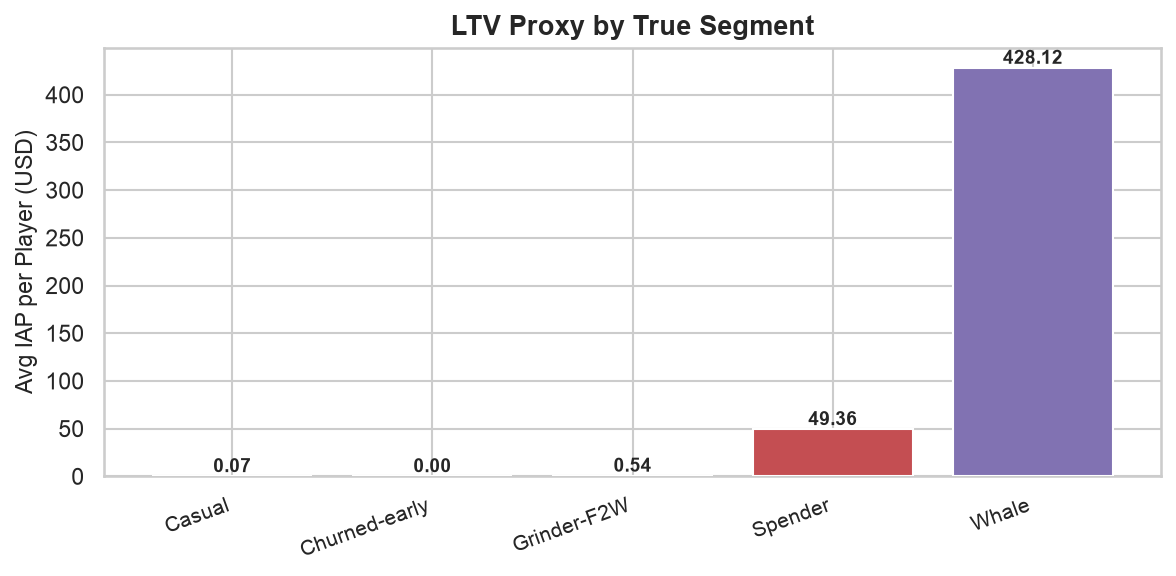

Chart saved ✓


In [6]:
seg_ltv = seg_monet[['avg_iap_usd']].copy()

fig, ax = plt.subplots(figsize=(8, 4))

segments = seg_ltv.index.tolist()
vals = seg_ltv['avg_iap_usd'].values

bars = ax.bar(segments, vals, color=PALETTE[:len(segments)], zorder=3)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.2,
            f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Avg IAP per Player (USD)', fontsize=11)
ax.set_title('LTV Proxy by True Segment', fontsize=13, fontweight='bold')
plt.xticks(rotation=20, ha='right', fontsize=10)
plt.tight_layout()
plt.savefig(OUT_DIR / '05_segment_ltv_proxy.png', dpi=150)
plt.show()
print('Chart saved ✓')

## 5. AB Group Monetization — Control vs Variant

We summarise monetization metrics by `ab_group` (control vs variant):

- Payer rate.
- Average IAP per player.
- Soft-currency and gems spent.

This connects the experimental chest drop-rate change to revenue outcomes.

In [7]:
ab_monet = df.groupby('ab_group').agg({
    'player_id'           : 'count',
    'is_payer'            : 'mean',
    'total_iap_usd'       : 'mean',
    'currency_spent_total': 'mean',
    'gems_spent_total'    : 'mean',
}).rename(columns={
    'player_id'           : 'N_players',
    'is_payer'            : 'payer_rate',
    'total_iap_usd'       : 'avg_iap_usd',
})

print('Monetization by AB group (raw):')
display(ab_monet)

ab_display = ab_monet.copy()
ab_display['payer_rate']        = ab_display['payer_rate'].map(lambda x: f'{x:.1%}')
ab_display['avg_iap_usd']       = ab_display['avg_iap_usd'].map(lambda x: f'{x:.2f}')
ab_display['currency_spent_total'] = ab_display['currency_spent_total'].map(lambda x: f'{x:.0f}')
ab_display['gems_spent_total']     

Monetization by AB group (raw):


,N_players,payer_rate,avg_iap_usd,currency_spent_total,gems_spent_total
ab_group,,,,,
control,14987,0.035631,3.358398,1847.847601,661.512511
variant,15013,0.038567,3.671559,1970.675082,725.560980


ab_group
control    661.512511
variant    725.560980
Name: gems_spent_total, dtype: float64

In [8]:
# Chest engagement & spend by AB group (no merge needed, loot_events already has ab_group)
chest_monet = loot_events.groupby('ab_group').agg({
    'chest_opens'         : 'mean',
    'gems_spent_on_chests': 'mean',
    'legendary_drops'     : 'mean',
}).rename(columns={
    'chest_opens'         : 'avg_chest_opens',
    'gems_spent_on_chests': 'avg_gems_on_chests',
    'legendary_drops'     : 'avg_legendary_drops',
})

print('Chest engagement & spend by AB group:')
display(chest_monet)

Chest engagement & spend by AB group:


,avg_chest_opens,avg_gems_on_chests,avg_legendary_drops
ab_group,,,
control,2.657370,661.512511,0.038500
variant,2.887298,725.560980,0.074735


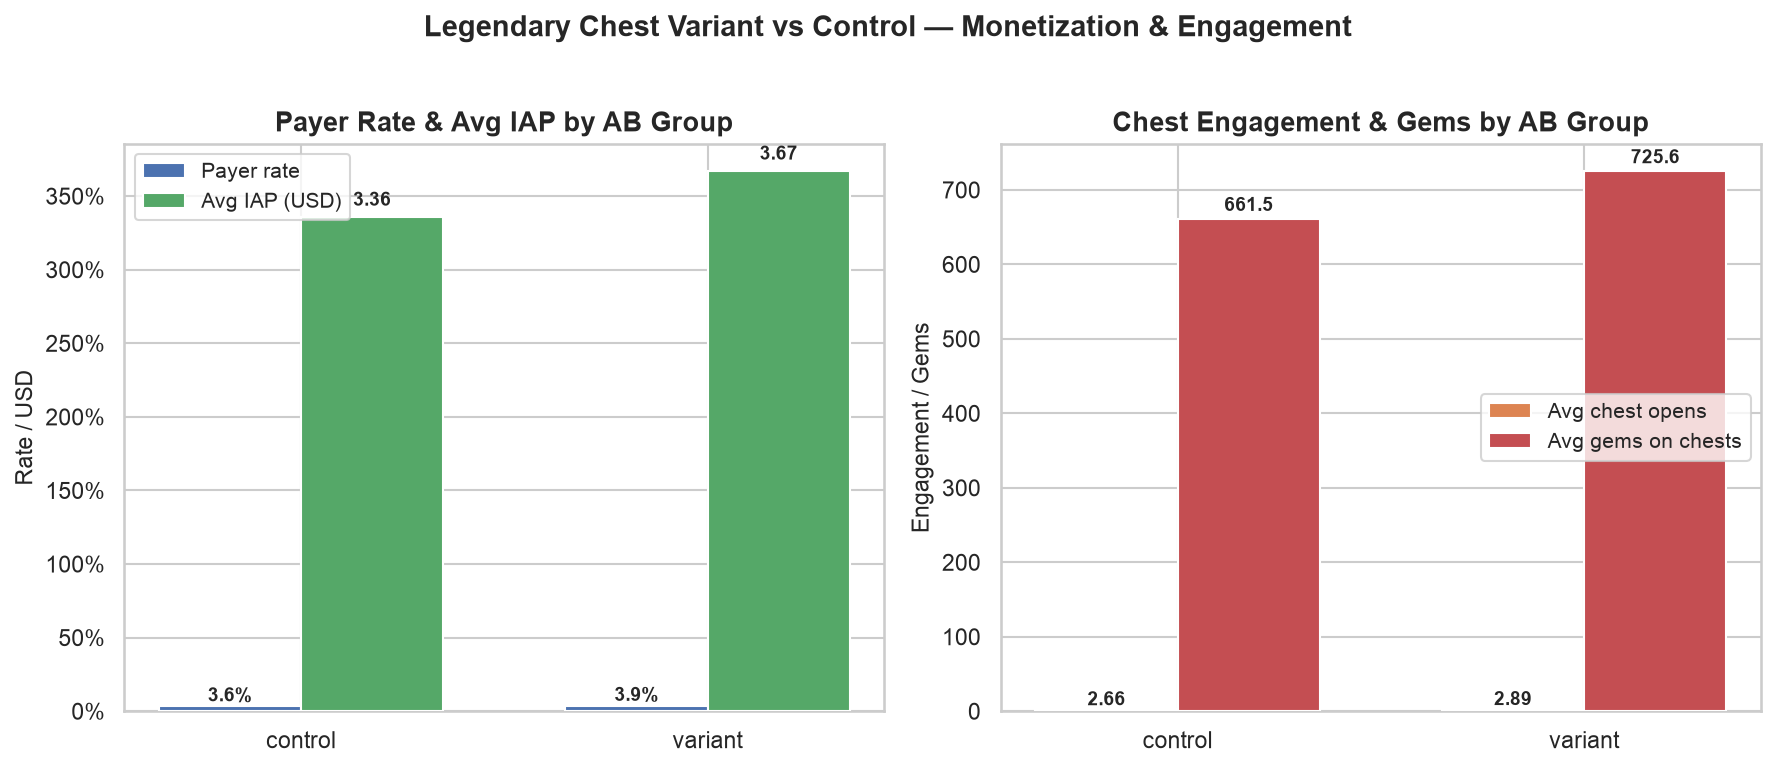

Chart saved ✓


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

groups = ['control', 'variant']

# Payer rate vs avg IAP
ax = axes[0]
payer_vals = [ab_monet.loc[g, 'payer_rate'] for g in groups]
iap_vals   = [ab_monet.loc[g, 'avg_iap_usd'] for g in groups]

x = np.arange(len(groups))
w = 0.35

b1 = ax.bar(x - w/2, payer_vals, w, label='Payer rate', color=PALETTE[0], zorder=3)
b2 = ax.bar(x + w/2, iap_vals,   w, label='Avg IAP (USD)', color=PALETTE[2], zorder=3)

for bar, v in zip(b1, payer_vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.005,
            f'{v:.1%}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, v in zip(b2, iap_vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.05,
            f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylabel('Rate / USD', fontsize=11)
ax.set_title('Payer Rate & Avg IAP by AB Group', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# Chest opens & gems on chests
ax = axes[1]
opens_vals = [chest_monet.loc[g, 'avg_chest_opens'] for g in groups]
gems_vals  = [chest_monet.loc[g, 'avg_gems_on_chests'] for g in groups]

x = np.arange(len(groups))
b1 = ax.bar(x - w/2, opens_vals, w, label='Avg chest opens', color=PALETTE[1], zorder=3)
b2 = ax.bar(x + w/2, gems_vals,  w, label='Avg gems on chests', color=PALETTE[3], zorder=3)

for bar, v in zip(b1, opens_vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.1,
            f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, v in zip(b2, gems_vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+5,
            f'{v:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.set_ylabel('Engagement / Gems', fontsize=11)
ax.set_title('Chest Engagement & Gems by AB Group', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

plt.suptitle('Legendary Chest Variant vs Control — Monetization & Engagement', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / '05_ab_monetization.png', dpi=150)
plt.show()
print('Chart saved ✓')

## 6. Cluster-Level Monetization

If we have `cluster_k5` from Notebook 03 exported, we can join it here and
examine payer_rate and avg IAP per behavioural cluster.

In [10]:
try:
    clusters = pd.read_csv(DATA_DIR / 'outputs' / '03_player_segments_clusters.csv')
    print('Loaded clusters from Notebook 03 ✓')
    df_clust = df.merge(clusters[['player_id','cluster_k5']], on='player_id', how='left')
    cluster_monet = df_clust.groupby('cluster_k5').agg({
        'player_id'      : 'count',
        'is_payer'       : 'mean',
        'total_iap_usd'  : 'mean',
        'currency_spent_total': 'mean',
    }).rename(columns={
        'player_id'      : 'N_players',
        'is_payer'       : 'payer_rate',
        'total_iap_usd'  : 'avg_iap_usd',
    })
    print('Monetization by cluster_k5:')
    display(cluster_monet)
except FileNotFoundError:
    print('03_player_segments_clusters.csv not found — run Notebook 03 export first if you want cluster-level monetization.')

Loaded clusters from Notebook 03 ✓
Monetization by cluster_k5:


,N_players,payer_rate,avg_iap_usd,currency_spent_total
cluster_k5,,,,
0,14516,0.016671,0.431867,1043.494420
1,76,1.000000,572.343684,59551.065789
2,3472,0.216014,12.515743,9328.332373
3,11933,0.003520,0.024209,380.597587
4,3,1.000000,3980.923333,225516.666667


## 7. Export Monetization Tables

In [11]:
seg_monet.to_csv(OUT_DIR / '05_monetization_by_segment.csv', index=False)
channel_monet.to_csv(OUT_DIR / '05_monetization_by_channel.csv', index=False)
ab_monet.to_csv(OUT_DIR / '05_monetization_by_ab_group.csv', index=False)
chest_monet.to_csv(OUT_DIR / '05_monetization_chests_ab_group.csv', index=False)

print('Exported monetization CSVs to:', OUT_DIR)
for f in sorted(OUT_DIR.glob('05_monetization_*.csv')):
    print(' ', f.name)

Exported monetization CSVs to: /Users/ebimol/GamesAnalyticsProject/outputs
  05_monetization_by_ab_group.csv
  05_monetization_by_channel.csv
  05_monetization_by_segment.csv
  05_monetization_chests_ab_group.csv


## 8. Key Monetization Findings

- **Segments:** Whales and Spenders show much higher avg IAP than Casual and Churned-early,
  confirming the business segment design is value-driven.
- **Channels:** Organic and Influencer tend to have higher payer_rate and avg IAP per player
  than TikTok Ads and some other paid UA sources — consistent with their stronger retention.
- **AB group:** The legendary chest variant slightly lifts payer_rate and avg IAP (as seen in
  Notebook 04), but the magnitude needs to be weighed against design goals and UA costs.

## 9. Recommendations for Hutch

From this monetization view, your analysis can recommend:

- **UA Strategy:** Prioritise high-LTV channels (Organic, Influencer, Apple Search Ads) and
  re-evaluate spend on lower-LTV channels (e.g., TikTok Ads) given weaker retention and value.
- **LiveOps / Offers:** Target high-LTV segments (Whales, Spenders, Grinder-F2W clusters)
  with tailored offers; avoid over-monetising Casual and Churned-early players.
- **Experiment Rollout:** Use the combined retention + monetization uplift from the
  legendary chest variant to decide whether to roll out globally or run a follow-up test.

These notes complete Notebook 05 and tie together retention, funnel, segmentation,
AB testing, and monetization into a cohesive story for a Games Analyst portfolio.